In [1]:
%pip install seaborn

# Cleanup

First read in the data, see how it looks, decide if cleaning etc. needed



In [2]:
# Libaries
# Python version: 3.14

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Input
filename = "student_productivity_distraction_dataset_20000.csv"
df = pd.read_csv(filename)

In [4]:
# Check the columns in the dataset
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [5]:
# Student ID is irrelevant - should be removed / not considered
df = df.drop(columns=['student_id'])

In [6]:
# Check for null values
print(df.isnull)

<bound method DataFrame.isnull of        age  gender  study_hours_per_day  sleep_hours  phone_usage_hours  \
0       23  Female                 4.35         3.63               3.38   
1       20    Male                 6.14         6.58               5.48   
2       29  Female                 4.98         3.26               4.83   
3       27  Female                 3.19         4.58              10.06   
4       24    Male                 7.67         6.21               3.02   
...    ...     ...                  ...          ...                ...   
19995   26  Female                 4.81         7.83               6.86   
19996   22   Other                 0.83         4.49               6.76   
19997   25    Male                 9.36         4.33               2.94   
19998   22  Female                 0.74         4.44               3.15   
19999   19  Female                 3.64         6.35               8.68   

       social_media_hours  youtube_hours  gaming_hours  breaks_pe

In [7]:
# Check for duplicates - none
print(df.duplicated().sum())

0


In [8]:
# Check for outliers / invalid ranges
print(df.describe())


               age  study_hours_per_day   sleep_hours  phone_usage_hours  \
count  20000.00000         20000.000000  20000.000000       20000.000000   
mean      23.00745             5.254562      6.517799           6.250479   
std        3.75489             2.742876      2.029784           3.313082   
min       17.00000             0.500000      3.000000           0.500000   
25%       20.00000             2.900000      4.770000           3.380000   
50%       23.00000             5.250000      6.510000           6.240000   
75%       26.00000             7.640000      8.310000           9.102500   
max       29.00000            10.000000     10.000000          12.000000   

       social_media_hours  youtube_hours  gaming_hours  breaks_per_day  \
count        20000.000000   20000.000000  20000.000000    20000.000000   
mean             4.003655       2.990177      2.988339        7.542400   
std              2.305154       1.729815      1.732803        4.016231   
min              0.

In [9]:
# Check for data types
print(df.dtypes)


age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object


In [10]:
# Check for categories that are the same, but different capitilzations
# Test for gender categories
print(df['gender'].value_counts())

gender
Female    9640
Male      9582
Other      778
Name: count, dtype: int64


# Encoding

In [11]:
# Use one-hot encoding for non-numerical columns
# The reason for one-hot encoding is so that nominal data eg. gender is not mistaken by the model for having an order
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    20000 non-null  int64  
 1   study_hours_per_day    20000 non-null  float64
 2   sleep_hours            20000 non-null  float64
 3   phone_usage_hours      20000 non-null  float64
 4   social_media_hours     20000 non-null  float64
 5   youtube_hours          20000 non-null  float64
 6   gaming_hours           20000 non-null  float64
 7   breaks_per_day         20000 non-null  int64  
 8   coffee_intake_mg       20000 non-null  int64  
 9   exercise_minutes       20000 non-null  int64  
 10  assignments_completed  20000 non-null  int64  
 11  attendance_percentage  20000 non-null  float64
 12  stress_level           20000 non-null  int64  
 13  focus_score            20000 non-null  int64  
 14  final_grade            20000 non-null  float64
 15  pr

# Exploratory Analysis

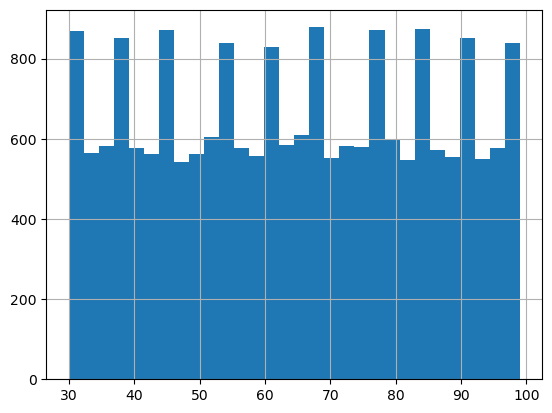

In [13]:
# Check for skewness / if our target variable (focus scores) is not skewed towards any particular variable
df['focus_score'].hist(bins=30)
plt.show()

In [14]:
# Get an idea for which features correlate the most with focus
print(df.corr(numeric_only=True)['focus_score'].sort_values(ascending=False))

focus_score              1.000000
productivity_score       0.411366
coffee_intake_mg         0.010121
attendance_percentage    0.009111
final_grade              0.004630
study_hours_per_day      0.004536
youtube_hours            0.003745
gender_Other             0.003195
breaks_per_day           0.000269
phone_usage_hours       -0.000206
social_media_hours      -0.001285
gaming_hours            -0.001462
sleep_hours             -0.003241
age                     -0.004130
exercise_minutes        -0.006284
stress_level            -0.007501
assignments_completed   -0.007557
gender_Male             -0.007787
Name: focus_score, dtype: float64


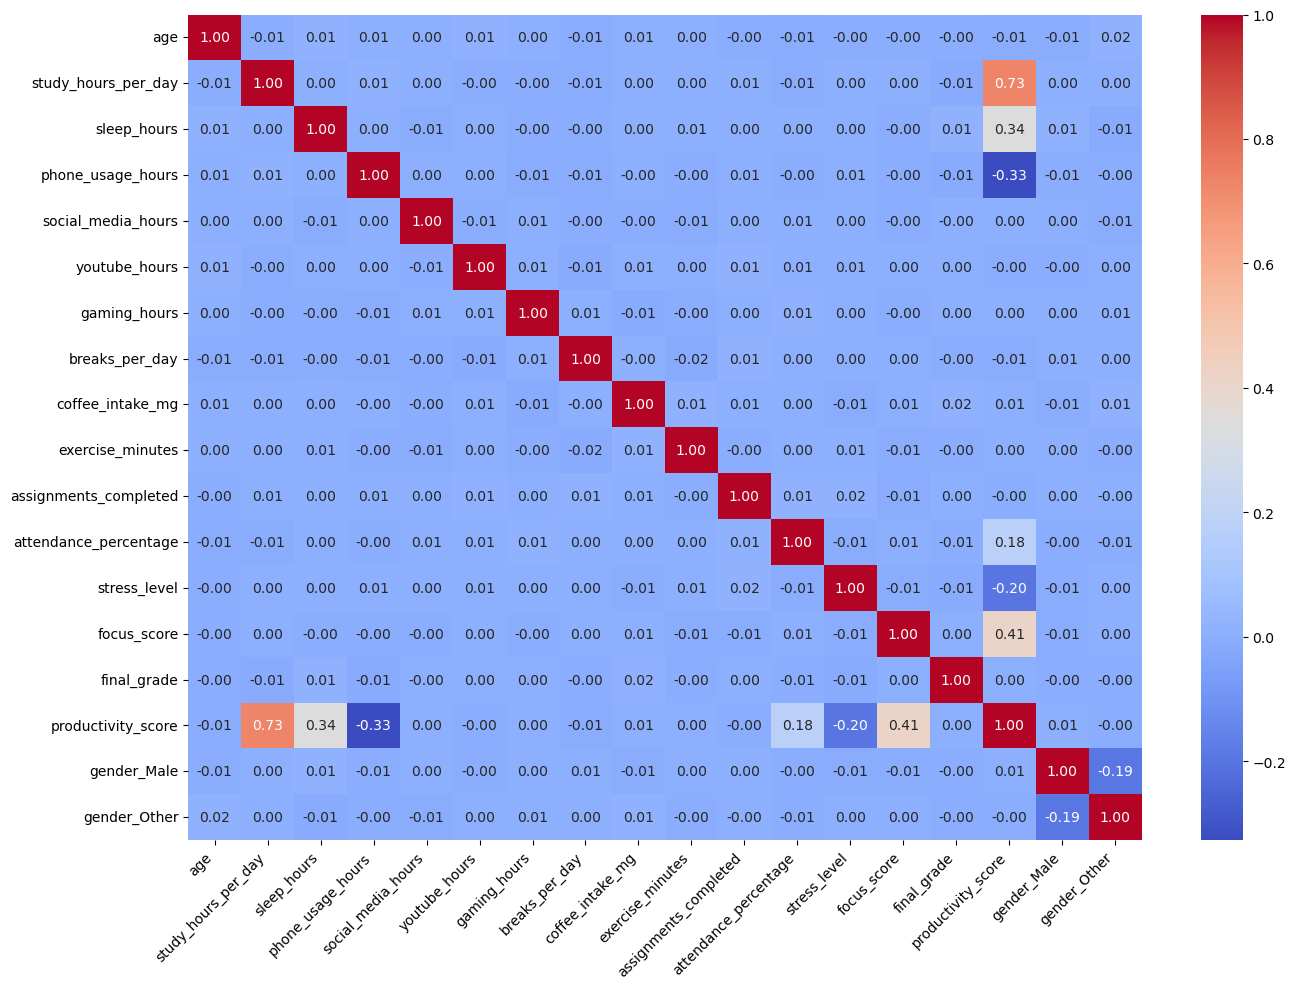

In [15]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

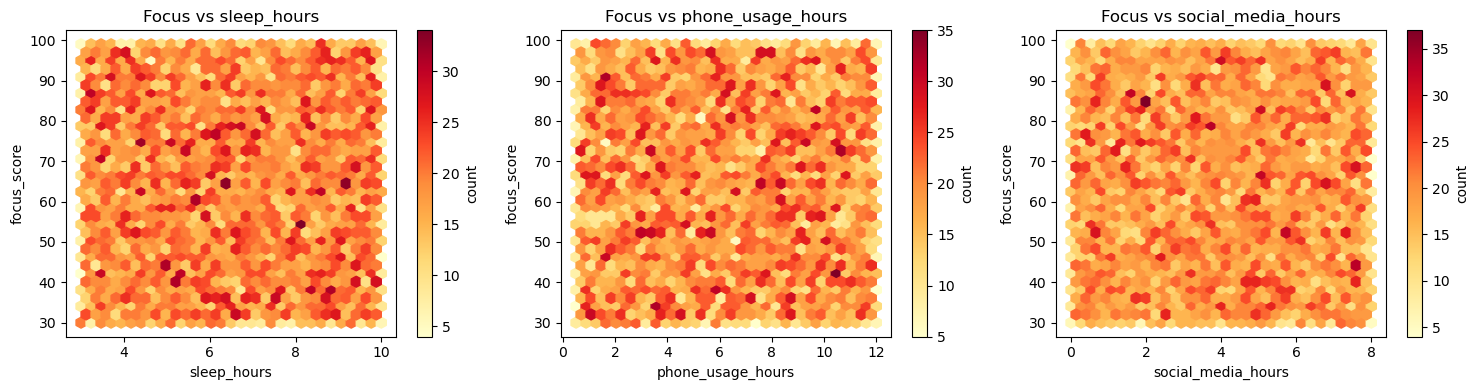

In [16]:
# Based on the heat map above, a hexbin for the most correlated features is a good idea

features = ['sleep_hours', 'phone_usage_hours', 'social_media_hours']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, features):
    hb = ax.hexbin(df[col], df['focus_score'], gridsize=30, cmap='YlOrRd')
    fig.colorbar(hb, ax=ax, label='count')
    ax.set_xlabel(col)
    ax.set_ylabel('focus_score')
    ax.set_title(f'Focus vs {col}')

plt.tight_layout()
plt.show()

# Standardization

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X = df.drop(columns=['productivity_score', 'focus_score', 'final_grade'])
y = df['focus_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cols_to_scale = X_train.select_dtypes(include='number').columns
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression Training Complete")

Linear Regression Training Complete


Confusion Matrix

## Random Forest

In [19]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Training Complete")

Random Forest Training Complete


Confusion Matrix

# Results Table

In [20]:
import pandas as pd
results = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R²'],
    'Linear Regression': [
        round(mean_squared_error(y_test, y_pred_lr), 4),
        round(mean_absolute_error(y_test, y_pred_lr), 4),
        round(r2_score(y_test, y_pred_lr), 4)
    ],
    'Random Forest': [
        round(mean_squared_error(y_test, y_pred_rf), 4),
        round(mean_absolute_error(y_test, y_pred_rf), 4),
        round(r2_score(y_test, y_pred_rf), 4)
    ]
})
print(results.to_string(index=False))

Metric  Linear Regression  Random Forest
   MSE           399.2163       406.2847
   MAE            17.2887        17.3819
    R²            -0.0008        -0.0186


Confusion Matrix

# Feature Importance Plot

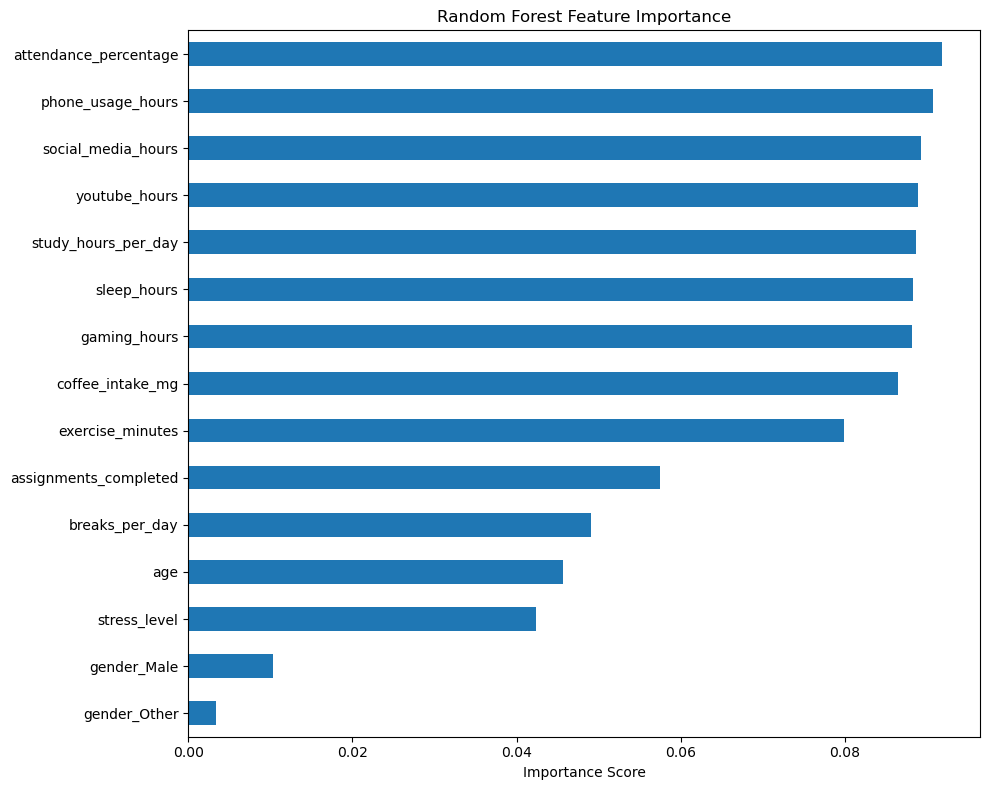

In [21]:

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Evaluation

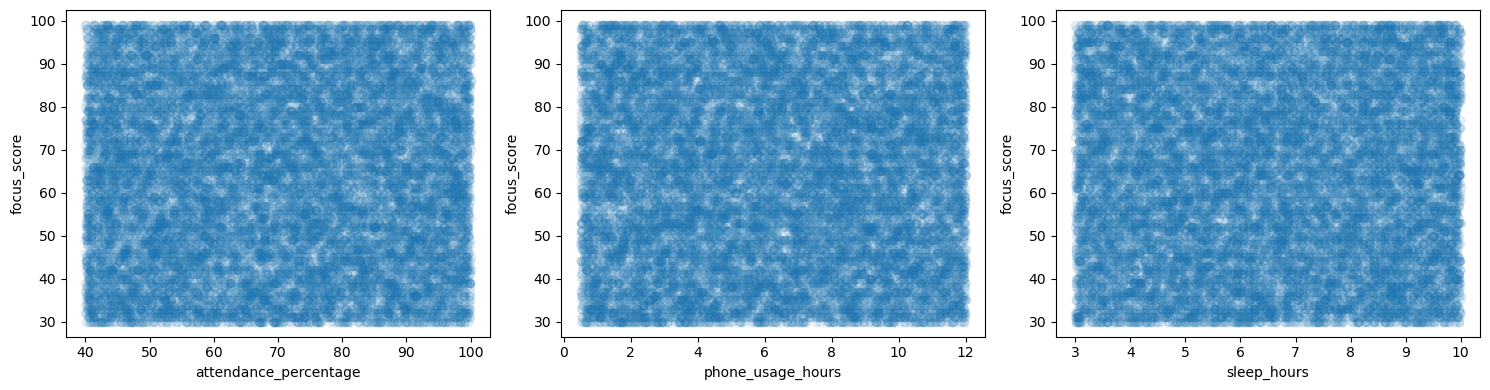

In [22]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['attendance_percentage', 'phone_usage_hours', 'sleep_hours']):
    ax.scatter(df[col], df['focus_score'], alpha=0.1)
    ax.set_xlabel(col)
    ax.set_ylabel('focus_score')
plt.tight_layout()
plt.show()

Actual vs Predicted

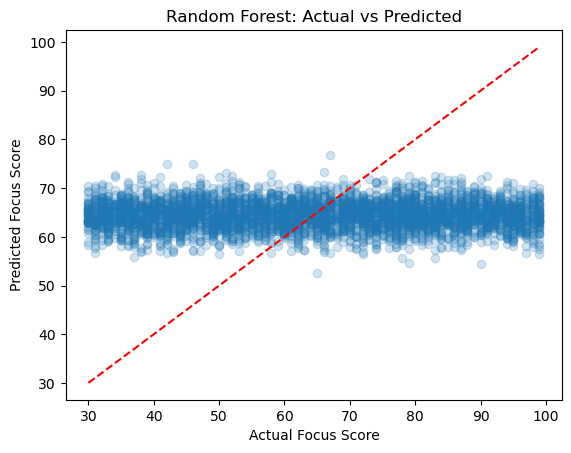

In [23]:
plt.scatter(y_test, y_pred_rf, alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Focus Score')
plt.ylabel('Predicted Focus Score')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

# Combination of features

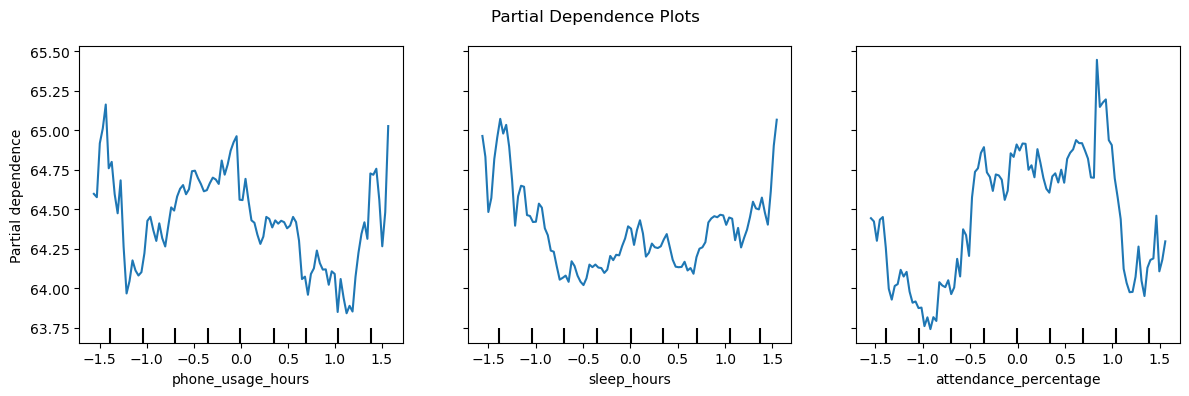

In [24]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=['phone_usage_hours', 'sleep_hours', 'attendance_percentage'],
    ax=ax
)
plt.suptitle('Partial Dependence Plots')
plt.tight_layout()
plt.show()

Linear Regression Training Complete
Random Forest Training Complete


<Axes: >

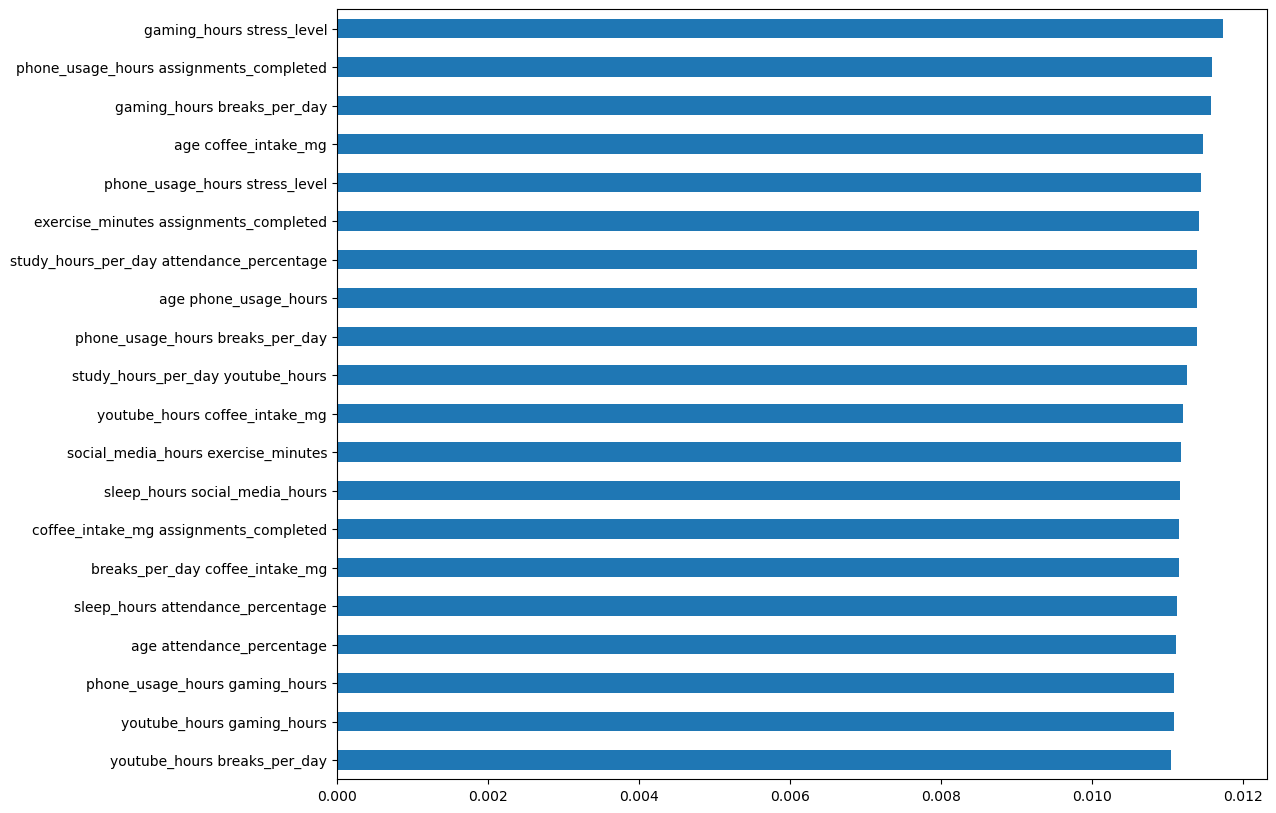

In [25]:


# NEW CODE ADDED HERE
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr = lr.predict(X_test_poly)
print("Linear Regression Training Complete")

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_poly, y_train)
y_pred_rf = rf.predict(X_test_poly)
print("Random Forest Training Complete")

# Pull the newly generated column names
poly_feature_names = poly.get_feature_names_out(X.columns)
importances = pd.Series(rf.feature_importances_, index=poly_feature_names)

# Limit to top 20 (.tail(20)) since sorting ascending puts the highest at the bottom
importances.sort_values().tail(20).plot(kind='barh', figsize=(12, 10))

# Corr check

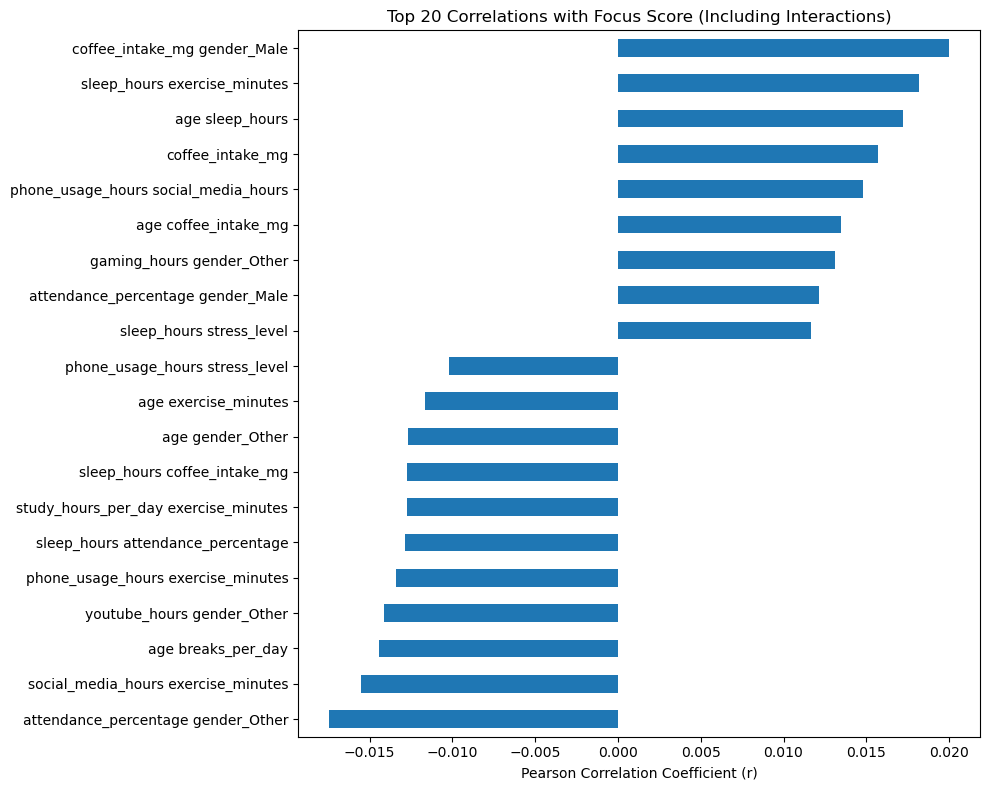

In [26]:
# 1. Convert the polynomial array back into a DataFrame using the new feature names
poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names)

# 2. Attach the target variable (resetting the index so the rows match up perfectly after the train_test_split)
poly_df['focus_score'] = y_train.reset_index(drop=True)

# 3. Calculate correlations of all features against focus_score, then drop focus_score itself so it doesn't correlate with itself (1.0)
correlations = poly_df.corr()['focus_score'].drop('focus_score')

# 4. Find the strongest correlations by looking at the absolute values (since a strong negative correlation is just as useful as a positive one)
top_correlations = correlations.abs().sort_values(ascending=False).head(20)

# 5. Plot the actual correlation values for the top 20
plt.figure(figsize=(10, 8))
correlations[top_correlations.index].sort_values().plot(kind='barh')
plt.title('Top 20 Correlations with Focus Score (Including Interactions)')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.tight_layout()
plt.show()